In [ ]:
!pip install pystac-client planetary-computer xarray netcdf4
!pip install contextily
!pip install netcdf4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pystac_client
import planetary_computer
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import requests
import os
import warnings
import scipy.ndimage as ndimage
from scipy.stats import binned_statistic_2d


In [ ]:
ARCHIVO_ENE_22 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2022_01.csv"
ARCHIVO_FEB_22 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2022_02.csv"
ARCHIVO_MAR_22 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2022_03.csv"
ARCHIVO_ABR_22 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2022_04.csv"
ARCHIVO_MAY_22 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2022_05.csv"


ARCHIVO_ENE_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_01.csv"
ARCHIVO_FEB_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_02.csv"
ARCHIVO_MAR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_03.csv"
ARCHIVO_ABR_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_04.csv"
ARCHIVO_MAY_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_05.csv"
ARCHIVO_JUN_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_06.csv"
ARCHIVO_JUL_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_07.csv"
ARCHIVO_AGO_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_08.csv"
ARCHIVO_SEP_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_09.csv"
ARCHIVO_OCT_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_10.csv"
ARCHIVO_NOV_23 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2023_11.csv"

ARCHIVO_ENE_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_01.csv"
ARCHIVO_FEB_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_02.csv"
ARCHIVO_MAR_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_03.csv"
ARCHIVO_ABR_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_04.csv"
ARCHIVO_MAY_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_05.csv"
ARCHIVO_JUN_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_06.csv"
ARCHIVO_JUL_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_07.csv"
ARCHIVO_AGO_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_08.csv"
ARCHIVO_SEP_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_09.csv"
ARCHIVO_OCT_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_10.csv"
ARCHIVO_NOV_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_11.csv"
ARCHIVO_DIC_24 = "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_12.csv"

# Ordenado cronológicamente para mantener el código limpio
archivos = [ARCHIVO_ENE_22, ARCHIVO_FEB_22, ARCHIVO_MAR_22, ARCHIVO_ABR_22, ARCHIVO_MAY_22,
            ARCHIVO_ENE_23, ARCHIVO_FEB_23, ARCHIVO_MAR_23, ARCHIVO_ABR_23, ARCHIVO_MAY_23,
            ARCHIVO_JUN_23, ARCHIVO_JUL_23, ARCHIVO_AGO_23, ARCHIVO_SEP_23, ARCHIVO_OCT_23,
            ARCHIVO_NOV_23, ARCHIVO_ENE_24, ARCHIVO_FEB_24, ARCHIVO_MAR_24, ARCHIVO_ABR_24,
            ARCHIVO_MAY_24, ARCHIVO_JUN_24, ARCHIVO_JUL_24, ARCHIVO_AGO_24, ARCHIVO_SEP_24,
            ARCHIVO_OCT_24, ARCHIVO_NOV_24, ARCHIVO_DIC_24]

# REPRESENTACOIÓN SUMA DE EXCESOS

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...
Calculando la suma de anomalías para todos los días...


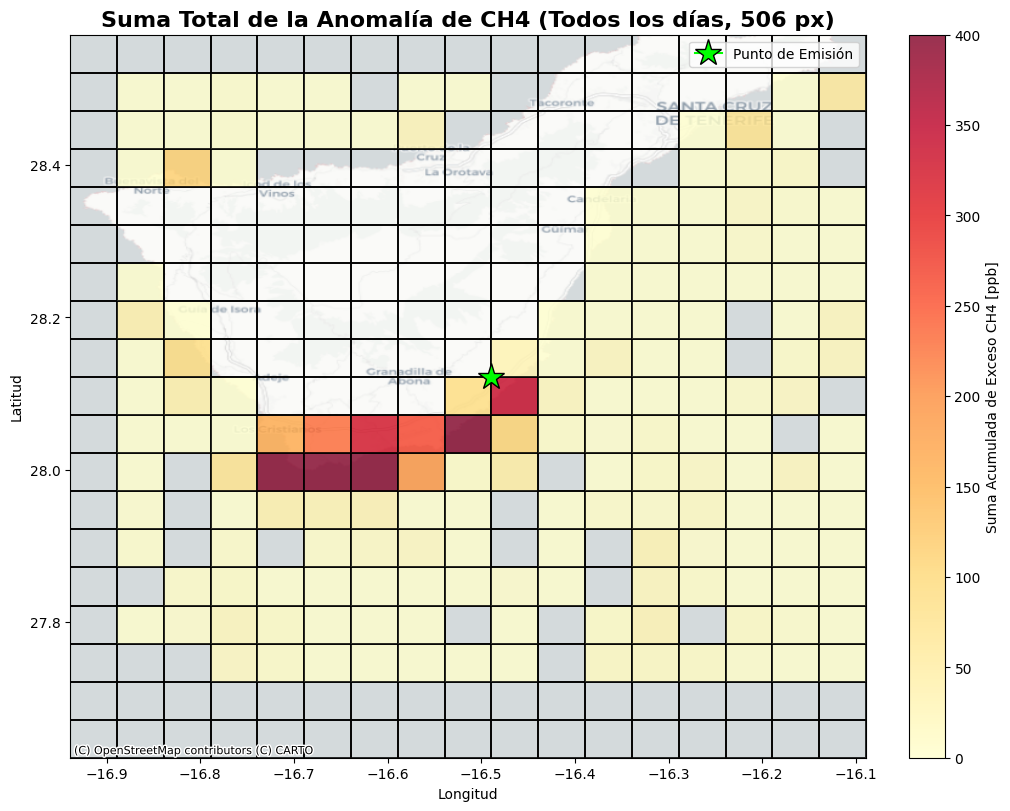

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import contextily as cx

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = -5, 25
RESOLUCION = 0.05
QA_VALUE = 0.5
VIENTO_MIN, VIENTO_MAX = 0.5, 5
LAT_CENTRO, LON_CENTRO = 28.121479, -16.489068

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.1
MASCARA_PIXEL = 2

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO / UPWIND BACKGROUND)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

mask_barlovento = diferencia_angular > 90
mask_anillo_limpio = (df['distancia'] >= 0.05) & (df['distancia'] <= 0.4) & mask_barlovento

fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()

fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 3. CÁLCULO ACUMULADO PARA TODOS LOS DÍAS (OVERSAMPLING)
# ==============================================================================
print("Calculando la suma de anomalías para todos los días...")

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling_suma(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)

    # 1. Calculamos la suma
    stat_sum, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='sum', bins=[lon_bins, lat_bins]
    )

    # 2. Calculamos cuántos píxeles hay realmente en cada celda
    stat_count, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='count', bins=[lon_bins, lat_bins]
    )

    # 3. Forzamos a que las celdas vacías sean NaN y no 0.0
    stat_sum[stat_count == 0] = np.nan

    return stat_sum.T

mapa_total = hacer_oversampling_suma(df)

# ==============================================================================
# 4. VISUALIZACIÓN DEL MAPA GENERAL
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Ocultamos los NaN de verdad usando una máscara de NumPy
mapa_visual = np.ma.masked_invalid(mapa_total)

# Usamos vmax dinámico
vmax_estimado = np.nanpercentile(mapa_total, 95) if not np.isnan(mapa_total).all() else VMAX

# Al usar la máscara arriba, pcolormesh dejará los huecos 100% transparentes
mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap="YlOrRd",
                     vmin=0, vmax=400, shading='flat',
                     alpha=0.8, edgecolor='black', linewidth=0.1)

# (El resto del código del mapa, la estrella y el plt.show() se queda exactamente igual)

# Estrella de la fuente (Tenerife)
ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=20,
        markeredgecolor='black', label="Punto de Emisión")

# Mapa base
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

ax.set_title(f"Suma Total de la Anomalía de CH4 (Todos los días, {len(df)} px)", fontsize=16, fontweight='bold')
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="upper right")

# Barra de color adaptada a "Suma"
plt.colorbar(mesh, ax=ax, label='Suma Acumulada de Exceso CH4 [ppb]', fraction=0.046, pad=0.04)

plt.show()

# REPRESENTACIÓN PROMEDIO EXCESO

Cargando y filtrando datos...
Calculando fondo diario estricto a barlovento...
Calculando la media de anomalías para todos los días...


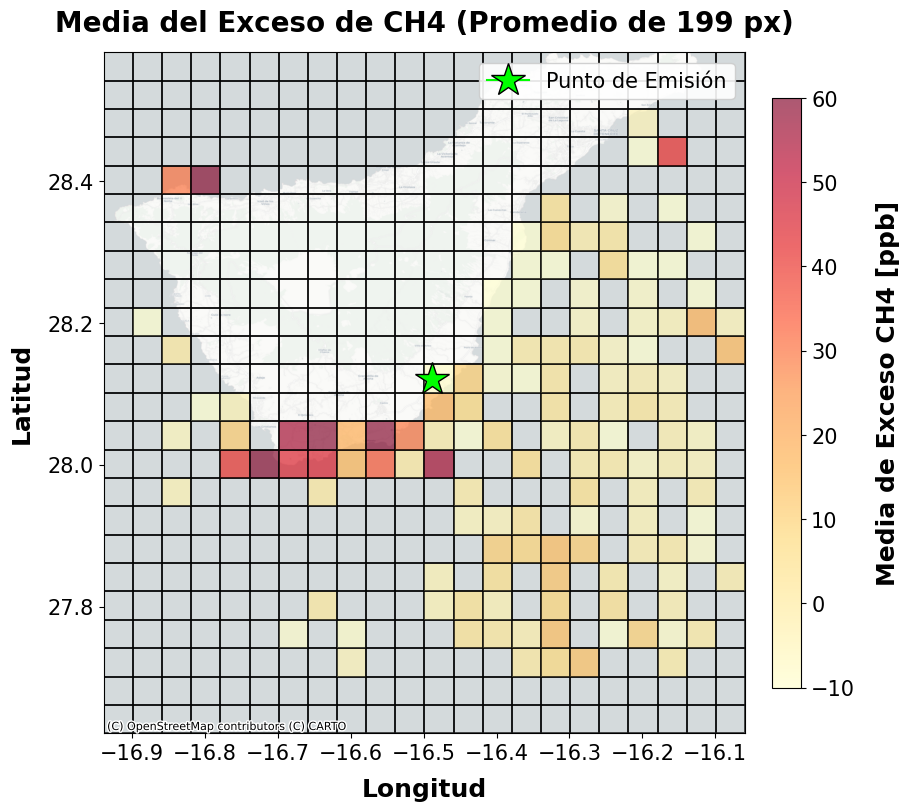

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import contextily as cx

# ==============================================================================
# PARÁMETROS GENERALES
# ==============================================================================
VMIN, VMAX = -5, 25
RESOLUCION = 0.04
QA_VALUE = 0.5
VIENTO_MIN, VIENTO_MAX = 0, 3
LAT_CENTRO, LON_CENTRO = 28.121479, -16.489068

# Filtro de calidad de datos por día
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 2

# ==============================================================================
# 1. CARGA, UNIÓN Y FILTRADO INICIAL
# ==============================================================================

print("Cargando y filtrando datos...")
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros básicos de calidad
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

# Crear columna de fecha limpia
df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed',  utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro: Solo días con suficientes píxeles cerca de la fuente
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA DIARIA (FONDO A BARLOVENTO / UPWIND BACKGROUND)
# ==============================================================================
print("Calculando fondo diario estricto a barlovento...")

df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

mask_barlovento = diferencia_angular > 90
mask_anillo_limpio = (df['distancia'] >= 0.05) & (df['distancia'] <= 0.4) & mask_barlovento

fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()

fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)



# ==============================================================================
# 3. CÁLCULO DE LA MEDIA PARA TODOS LOS DÍAS (OVERSAMPLING)
# ==============================================================================
print("Calculando la media de anomalías para todos los días...")

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling_media(datos_df, variable='metano_anomalia'):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)

    # Cambiamos 'sum' por 'mean'
    stat_mean, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df[variable],
        statistic='mean', bins=[lon_bins, lat_bins]
    )

    # El resultado de 'mean' ya pone NaN automáticamente donde no hay datos
    return stat_mean.T

mapa_total = hacer_oversampling_media(df)

# ==============================================================================
# 4. VISUALIZACIÓN DEL MAPA GENERAL (TAMAÑOS AUMENTADOS)
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)

# Ocultamos los NaN
mapa_visual = np.ma.masked_invalid(mapa_total)

# AJUSTE DE ESCALA
vmax_plot = np.nanpercentile(mapa_total, 98) if not np.isnan(mapa_total).all() else VMAX

mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap="YlOrRd",
                     vmin=-10, vmax=60, shading='flat',
                     alpha=0.65, edgecolor='black', linewidth=0.1)

# Estrella de la fuente (Tenerife)
ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=25,
        markeredgecolor='black', label="Punto de Emisión")

# Mapa base
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zoom=12)

# ================= AJUSTES DE TAMAÑO DE FUENTE =================

# Título del gráfico
ax.set_title(f"Media del Exceso de CH4 (Promedio de {len(df)} px)",
             fontsize=20, fontweight='bold', pad=15)

# Etiquetas de los ejes X e Y
ax.set_xlabel("Longitud", fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel("Latitud", fontsize=18, fontweight='bold', labelpad=10)

# "Numeritos" de los ejes (ticks)
ax.tick_params(axis='both', which='major', labelsize=15)

# Leyenda
ax.legend(loc="upper right", fontsize=15, framealpha=0.9)

# Barra de color
cbar = plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Media de Exceso CH4 [ppb]', fontsize=18, fontweight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=15) # Numeritos de la barra de color

plt.show()

Calculando el conteo de píxeles para todos los días...


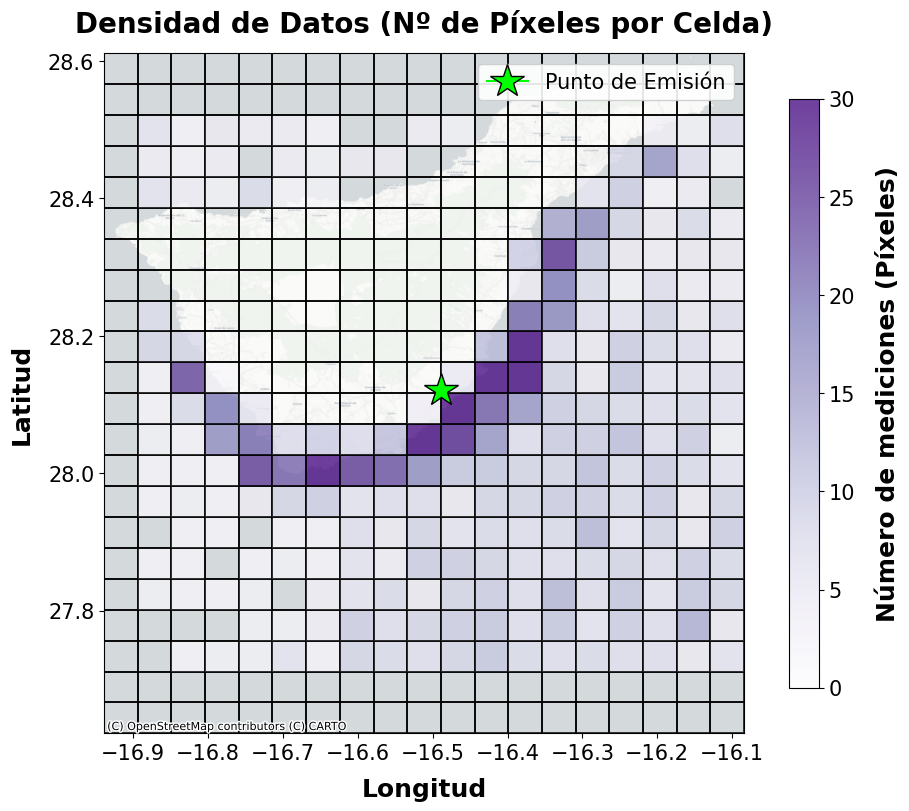

In [ ]:
# ==============================================================================
# 3B. CÁLCULO DE LA DENSIDAD (NÚMERO DE PÍXELES POR CELDA)
# ==============================================================================
print("Calculando el conteo de píxeles para todos los días...")

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling_conteo(datos_df):
    if len(datos_df) == 0:
        return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)

    # Cambiamos 'mean' por 'count' y quitamos la 'variable' porque solo queremos contar
    stat_count, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], values=None,
        statistic='count', bins=[lon_bins, lat_bins]
    )

    return stat_count.T

mapa_conteo = hacer_oversampling_conteo(df)

# ==============================================================================
# 4B. VISUALIZACIÓN DEL MAPA DE CONTEOS
# ==============================================================================
fig2, ax2 = plt.subplots(figsize=(9, 8), constrained_layout=True)

# Ocultamos las celdas donde el conteo es 0
mapa_visual_conteo = np.ma.masked_where(mapa_conteo == 0, mapa_conteo)

# Ajuste de escala: mostramos desde 1 píxel hasta el máximo percentil
vmax_conteo = np.nanpercentile(mapa_conteo[mapa_conteo > 0], 98) if np.any(mapa_conteo > 0) else 100

# Usamos 'Purples' (Morados) o 'Blues' para diferenciarlo del mapa de anomalía
mesh2 = ax2.pcolormesh(lon_bins, lat_bins, mapa_visual_conteo, cmap="Purples",
                     vmin=0, vmax=30, shading='flat',
                     alpha=0.75, edgecolor='black', linewidth=0.1)

# Estrella de la fuente (Tenerife)
ax2.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=25,
        markeredgecolor='black', label="Punto de Emisión")

# Mapa base
cx.add_basemap(ax2, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zoom=12)

# ================= AJUSTES DE TAMAÑO DE FUENTE =================

# Título del gráfico
ax2.set_title(f"Densidad de Datos (Nº de Píxeles por Celda)",
             fontsize=20, fontweight='bold', pad=15)

# Etiquetas de los ejes X e Y
ax2.set_xlabel("Longitud", fontsize=18, fontweight='bold', labelpad=10)
ax2.set_ylabel("Latitud", fontsize=18, fontweight='bold', labelpad=10)

# "Numeritos" de los ejes (ticks)
ax2.tick_params(axis='both', which='major', labelsize=15)

# Leyenda
ax2.legend(loc="upper right", fontsize=15, framealpha=0.9)

# Barra de color
cbar2 = plt.colorbar(mesh2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Número de mediciones (Píxeles)', fontsize=18, fontweight='bold', labelpad=15)
cbar2.ax.tick_params(labelsize=15)

plt.show()

Iniciando procesamiento de datos...
Calculando fondo diario...


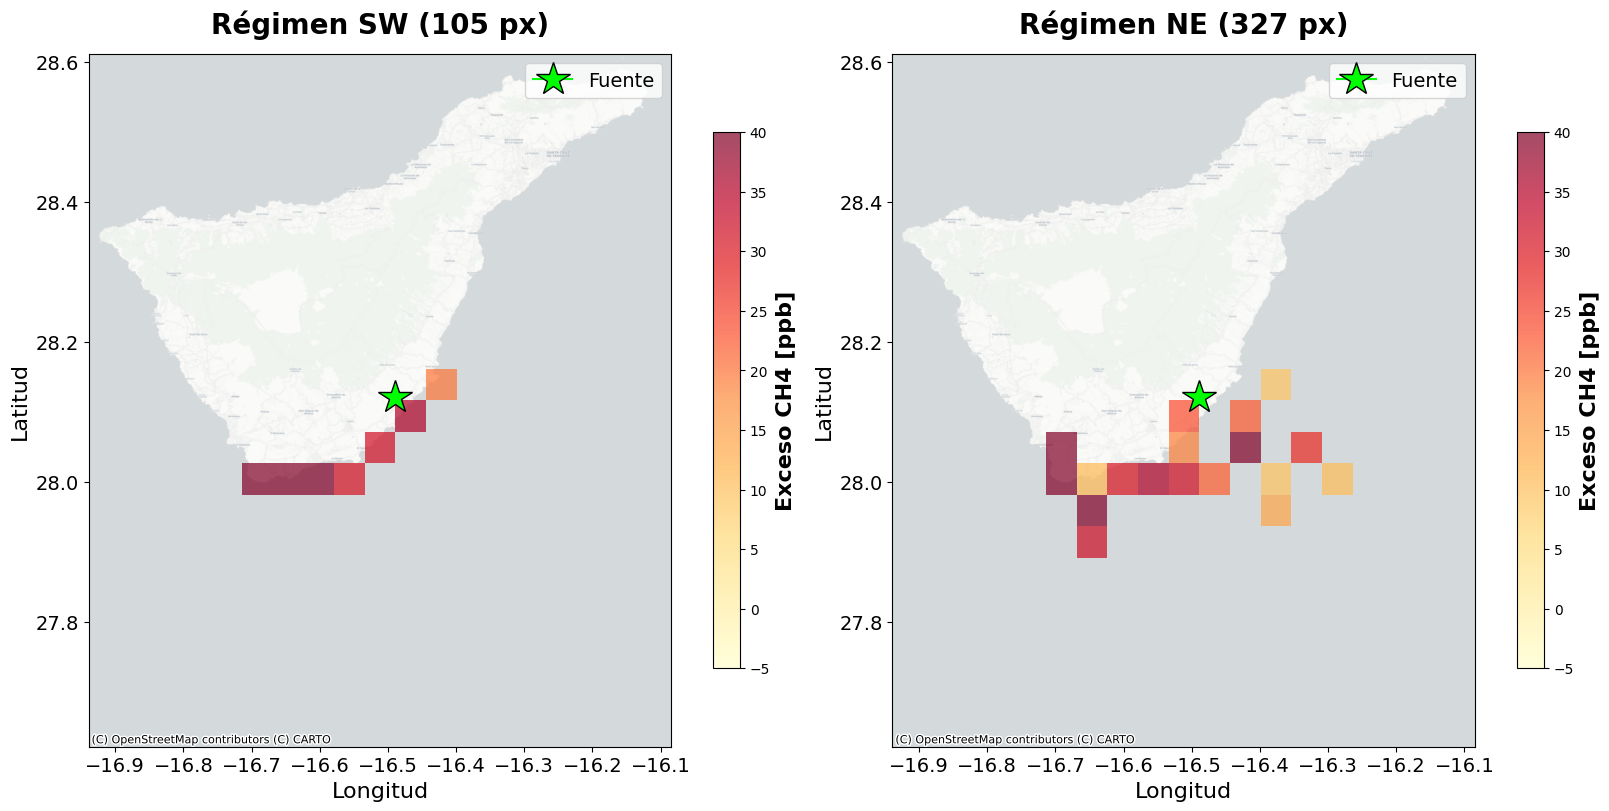


 RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME)
📍 Régimen Suroeste (SW):
   Viento medio: 4.02 m/s | U_eff: 1.99 m/s
   Q (1.5/2.0/2.5 sigma): [np.float64(21.37), np.float64(21.37), np.float64(21.37)] t/h
   ➡️ EMISIÓN FINAL: 21.37 ± 4.01 t/h
   (Error Relativo: 18.8%)
📍 Régimen Noreste (NE):
   Viento medio: 5.27 m/s | U_eff: 2.26 m/s
   Q (1.5/2.0/2.5 sigma): [np.float64(24.88), np.float64(25.27), np.float64(25.65)] t/h
   ➡️ EMISIÓN FINAL: 25.27 ± 3.19 t/h
   (Error Relativo: 12.6%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy.stats import binned_statistic_2d
from scipy import ndimage

# ==============================================================================
# 1. PARÁMETROS GENERALES Y CONFIGURACIÓN
# ==============================================================================
# Coordenadas: Complejo Ambiental de Tenerife (Arico)
LAT_CENTRO, LON_CENTRO = 28.121479, -16.489068
VMIN, VMAX = -5, 25
RESOLUCION = 0.045
QA_VALUE = 0.3  # Si sale vacío, bajar a 0.3 o 0.4
VIENTO_MIN, VIENTO_MAX = 0, 7
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 2

# Parámetros Físicos para IME
PRESION_ARICO = 95400  # Pa (ajustada a la altitud de la fuente)
M_CH4 = 0.01604        # kg/mol
M_AIRE = 0.02896       # kg/mol
G = 9.81               # m/s^2
ALPHA_1 = 1.0          # Varon et al. 2018
ALPHA_2 = 0.6          # m/s
SIGMA_U10 = 1.5        # Error típico ERA5 (m/s)

print("Iniciando procesamiento de datos...")

# ==============================================================================
# 2. CARGA Y FILTRADO INICIAL
# ==============================================================================
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros de calidad y viento
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro de representatividad diaria
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

# Dirección del viento (De dónde viene)
df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 3. CÁLCULO DE ANOMALÍA (FONDO A BARLOVENTO)
# ==============================================================================
print("Calculando fondo diario...")
df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

mask_barlovento = diferencia_angular > 90
mask_anillo_limpio = (df['distancia'] >= 0.05) & (df['distancia'] <= 0.4) & mask_barlovento

fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 4. OVERSAMPLING Y AISLAMIENTO DE PLUMA
# ==============================================================================
df_sw = df[(df['dir_viento'] >= 190) & (df['dir_viento'] <= 260)].copy()
df_ne = df[(df['dir_viento'] >= 10)  & (df['dir_viento'] <= 80)].copy()

lat_bins = np.arange(LAT_CENTRO - 0.5, LAT_CENTRO + 0.5, RESOLUCION)
lon_bins = np.arange(LON_CENTRO - 0.45, LON_CENTRO + 0.45, RESOLUCION)

def hacer_oversampling_media(datos_df):
    if len(datos_df) == 0: return np.full((len(lat_bins)-1, len(lon_bins)-1), np.nan)
    stat, _, _, _ = binned_statistic_2d(
        datos_df['lon'], datos_df['lat'], datos_df['metano_anomalia'],
        statistic='mean', bins=[lon_bins, lat_bins]
    )
    return stat.T

mapa_sw_bruto = hacer_oversampling_media(df_sw)
mapa_ne_bruto = hacer_oversampling_media(df_ne)
def aislar_pluma_tenerife(mapa, umbral_ppb, radio_max=0.3, min_pixeles=3):
    """
    Aísla únicamente la pluma conectada a la fuente.

    - Elimina píxeles aislados en el mar
    - Mantiene continuidad espacial
    - Conserva solo la estructura conectada a la fuente
    """

    # ----------------------------------------------------------
    # 1. MÁSCARA INICIAL
    # ----------------------------------------------------------
    lon_mesh, lat_mesh = np.meshgrid(lon_bins[:-1], lat_bins[:-1])

    dist_map = np.sqrt(
        (lon_mesh - LON_CENTRO)**2 +
        (lat_mesh - LAT_CENTRO)**2
    )

    mascara = (
        (mapa > umbral_ppb) &
        (dist_map < radio_max) &
        (~np.isnan(mapa))
    )

    # ----------------------------------------------------------
    # 2. COMPONENTES CONECTADAS
    # ----------------------------------------------------------
    estructura = ndimage.generate_binary_structure(2, 2)

    etiquetas, num = ndimage.label(mascara, structure=estructura)

    if num == 0:
        return np.full_like(mapa, np.nan)

    # ----------------------------------------------------------
    # 3. ENCONTRAR PIXEL MÁS CERCANO A LA FUENTE
    # ----------------------------------------------------------
    dist_fuente = np.sqrt(
        (lon_mesh - LON_CENTRO)**2 +
        (lat_mesh - LAT_CENTRO)**2
    )

    dist_fuente[~mascara] = np.inf

    iy, ix = np.unravel_index(
        np.argmin(dist_fuente),
        dist_fuente.shape
    )

    etiqueta_fuente = etiquetas[iy, ix]

    if etiqueta_fuente == 0:
        return np.full_like(mapa, np.nan)

    # ----------------------------------------------------------
    # 4. CONSERVAR SOLO ESA COMPONENTE
    # ----------------------------------------------------------
    mascara_final = etiquetas == etiqueta_fuente

    # ----------------------------------------------------------
    # 5. ELIMINAR ESTRUCTURAS PEQUEÑAS
    # ----------------------------------------------------------
    if np.sum(mascara_final) < min_pixeles:
        return np.full_like(mapa, np.nan)

    # ----------------------------------------------------------
    # 6. MAPA FINAL
    # ----------------------------------------------------------
    mapa_limpio = np.where(mascara_final, mapa, np.nan)

    return mapa_limpio

# ==============================================================================
# CÁLCULO DE SIGMA DEL FONDO
# ==============================================================================

fondo_sw = mapa_sw_bruto[
    mapa_sw_bruto < np.nanpercentile(mapa_sw_bruto, 50)
]

fondo_ne = mapa_ne_bruto[
    mapa_ne_bruto < np.nanpercentile(mapa_ne_bruto, 50)
]

sigma_sw = np.nanstd(fondo_sw) if len(fondo_sw) > 0 else 2.0
sigma_ne = np.nanstd(fondo_ne) if len(fondo_ne) > 0 else 2.0

# Limitar valores extremos
sigma_sw = np.clip(sigma_sw, 0.8, 5.0)
sigma_ne = np.clip(sigma_ne, 0.8, 5.0)

# ==============================================================================
# MAPAS PARA DIFERENTES UMBRALES SIGMA
# ==============================================================================

SIGMAS = [1.5, 2.0, 2.5]

mapas_sw = [
    aislar_pluma_tenerife(mapa_sw_bruto, s * sigma_sw)
    for s in SIGMAS
]

mapas_ne = [
    aislar_pluma_tenerife(mapa_ne_bruto, s * sigma_ne)
    for s in SIGMAS
]


# ==============================================================================
# 5. VISUALIZACIÓN (CORREGIDA PARA EVITAR EL ERROR DE SOLO LECTURA)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

for i, (lista_mapas, datos_dir, titulo) in enumerate(zip([mapas_sw, mapas_ne], [df_sw, df_ne], ["SW", "NE"])):
    ax = axes[i]
    mapa_original = lista_mapas[0]  # El mapa de 1.5 sigma

    # Verificamos si hay datos antes de calcular el percentil
    pixeles_validos = mapa_original[~np.isnan(mapa_original)]

    if len(pixeles_validos) > 0:
        # Calculamos vmax usando los datos limpios (sin máscara de Numpy)
        vmax_auto = np.percentile(pixeles_validos, 99)
        # Si el valor es muy bajo, ponemos un mínimo para que el color se vea bien
        vmax_auto = max(vmax_auto, 5)

        # Creamos la máscara para el plot
        mapa_visual = np.ma.masked_invalid(mapa_original)

        mesh = ax.pcolormesh(lon_bins, lat_bins, mapa_visual, cmap="YlOrRd",
                             vmin=-5, vmax=40, shading='flat', alpha=0.7)

        cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Exceso CH4 [ppb]', fontsize=16, fontweight='bold')
    else:
        ax.text(0.5, 0.5, "Sin pluma detectable", ha='center', va='center', transform=ax.transAxes)

    # Dibujamos la estrella y el mapa base
    ax.plot(LON_CENTRO, LAT_CENTRO, marker='*', color='lime', markersize=25,
            markeredgecolor='black', label="Fuente")

    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zoom=12)

    # Formato de fuentes grandes
    ax.set_title(f"Régimen {titulo} ({len(datos_dir)} px)", fontsize=20, fontweight='bold', pad=15)
    ax.tick_params(labelsize=14)
    ax.set_xlabel("Longitud", fontsize=16); ax.set_ylabel("Latitud", fontsize=16)
    ax.legend(fontsize=14)

plt.show()

# ==============================================================================
# 6. CUANTIFICACIÓN IME Y CÁLCULO DE ERRORES
# ==============================================================================
print("\n" + "="*60)
print(" RESULTADOS DE CUANTIFICACIÓN (MÉTODO IME)")
print("="*60)

# Constantes de área
col_aire_kg = PRESION_ARICO / (M_AIRE * G)
area_px = (RESOLUCION * 111320) * (RESOLUCION * 111320 * np.cos(np.radians(LAT_CENTRO)))

def calcular_flujo(mapa, u_eff):
    pixeles = mapa[~np.isnan(mapa)]
    if len(pixeles) == 0: return 0
    # IME = Suma(exceso_kg_m2 * area_pixel)
    ime_kg = np.sum(pixeles * 1e-9 * col_aire_kg * M_CH4 * area_px)
    L = np.sqrt(len(pixeles) * area_px)
    Q = (ime_kg * u_eff) / L
    return Q

def procesar_regimen(mapas, df_viento, nombre):
    if len(df_viento) == 0: return

    v_10 = df_viento['v_modulo'].mean()
    u_eff = ALPHA_1 * np.log(v_10) + ALPHA_2

    # Flujos para los 3 umbrales
    qs = [calcular_flujo(m, u_eff) for m in mapas]
    qs_validos = [q for q in qs if q > 0]

    if not qs_validos:
        print(f"📍 {nombre}: No se detectó pluma.")
        return

    q_media = np.mean(qs_validos)

    # Error Viento
    err_viento = ((ALPHA_1 / v_10) * SIGMA_U10) / u_eff
    # Error Segmentación (Desviación estándar de los 3 umbrales)
    err_seg = (np.std(qs_validos) / q_media) if len(qs_validos) > 1 else 0
    err_total = np.sqrt(err_viento**2 + err_seg**2)

    print(f"📍 {nombre}:")
    print(f"   Viento medio: {v_10:.2f} m/s | U_eff: {u_eff:.2f} m/s")
    print(f"   Q (1.5/2.0/2.5 sigma): {[round(q*3.6, 2) for q in qs]} t/h")
    print(f"   ➡️ EMISIÓN FINAL: {q_media*3.6:.2f} ± {(q_media*3.6)*err_total:.2f} t/h")
    print(f"   (Error Relativo: {err_total*100:.1f}%)")

procesar_regimen(mapas_sw, df_sw, "Régimen Suroeste (SW)")
procesar_regimen(mapas_ne, df_ne, "Régimen Noreste (NE)")

# CUANTIFICAR MÉTODO IME IMPLEMENTADO EN MADRID

# CUANTIFICAR (AL FINAL NO HEMOS UTILIZADO ESTE BLOQUE QUE CUANTIIFCA POR DÍAS SUELTOS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Cargando datos y ejecutando cálculos de Q para Arico...

📊 RESULTADOS FINALES - VERTEDERO DE ARICO
📌 Días cuantificados: 5
📌 Media Simple: 6.84 ± 6.28 ton/h
📌 Media Ponderada: 2.99 ± 0.18 ton/h


,Fecha,Emisión Q (ton/h),Incertidumbre Abs (ton/h),Error Relativo (%),Viento U10 (m/s),Sigma Fondo (ppb)
0,2024-03-20,2.714672,0.279313,10.289030,6.25,0.000000
1,2024-05-02,4.382999,0.474714,10.830806,6.03,5.045754
2,2024-05-12,17.656000,2.744765,15.545793,6.85,19.662513
4,2024-06-24,6.829375,2.391833,35.022717,2.80,11.414828
7,2024-09-12,2.617989,0.268751,10.265558,6.26,0.000000


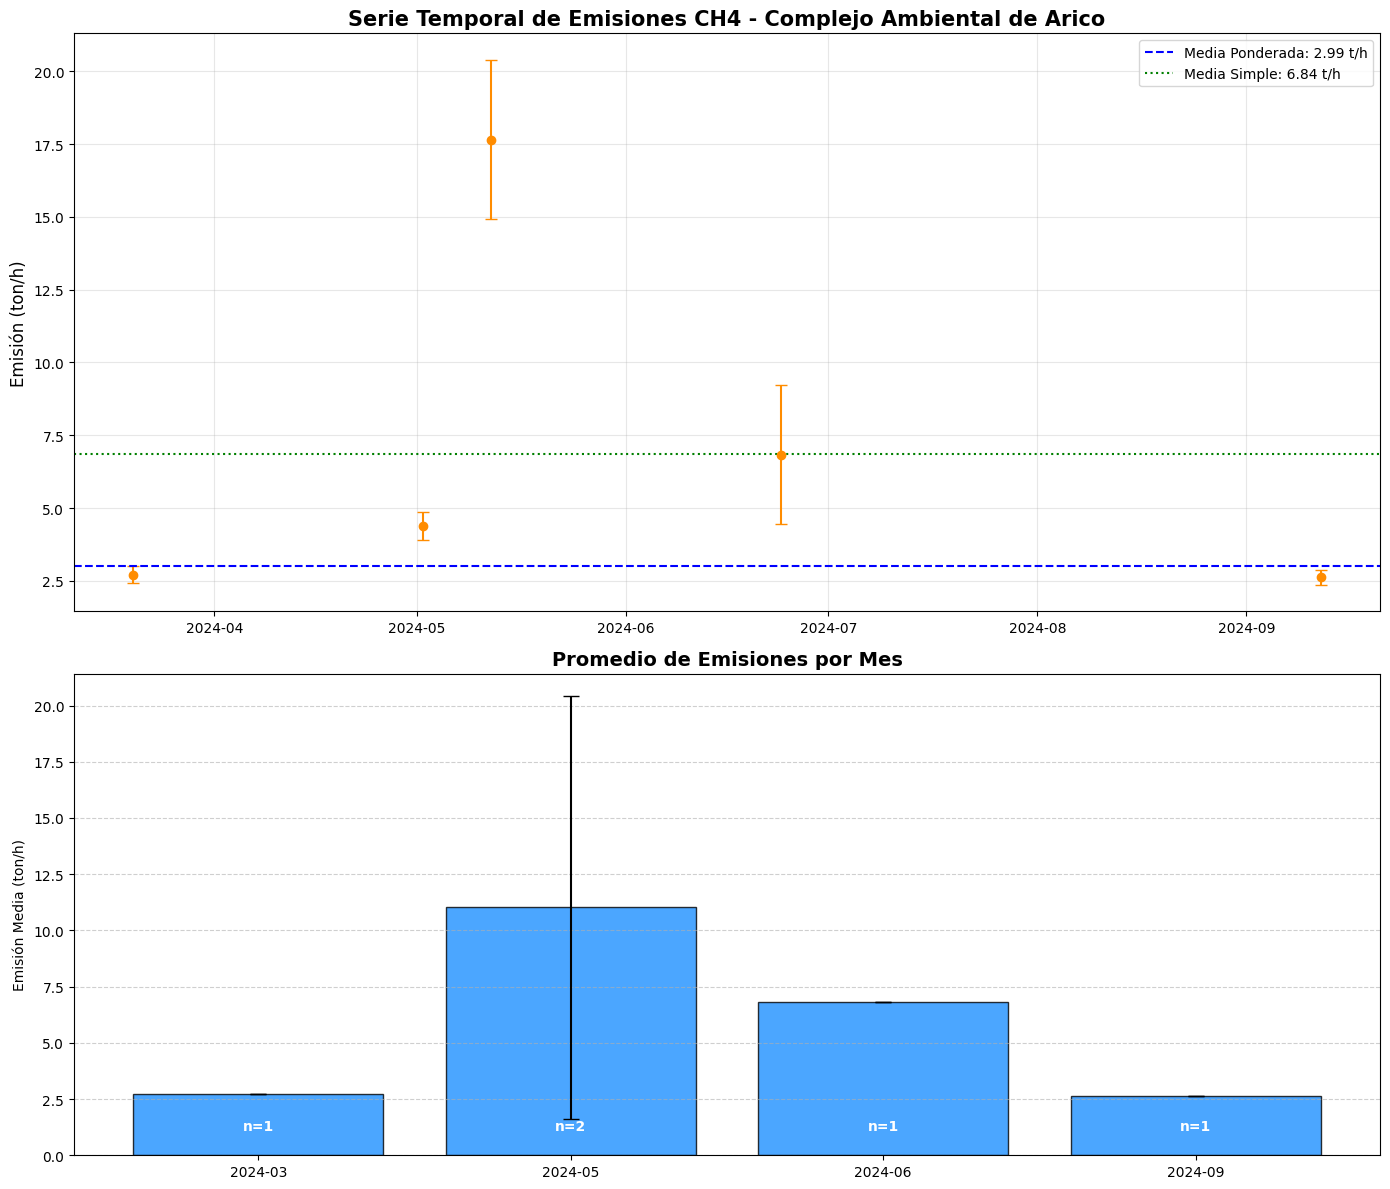

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
from google.colab import drive
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CONEXIÓN A DRIVE Y CONFIGURACIÓN
# ==============================================================================
drive.mount('/content/drive')

# Archivos de Tenerife (Ajusta los meses según los que tengas descargados)
archivos_csv = [
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_01.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_02.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_03.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_04.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_05.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_06.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_07.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_08.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_09.csv",
    "/content/drive/MyDrive/Sexto/PRACTICAS_CSIC_IPNA/TFN/TROPOMI_Tenerife_2024_10.csv"

]

# Constantes del Vertedero de Arico (Tenerife) y Físicas
LAT_ARICO, LON_ARICO = 28.121479, -16.489068
AREA_PIXEL = 7000 * 5500
ALPHA_1, ALPHA_2 = 1.0, 0.5  # Parámetros U_eff

# Parámetros de Filtrado
QA_VALUE = 0.5
VIENTO_MIN, VIENTO_MAX = 1.5, 10.0
MASCARA_RADIO, MASCARA_PIXEL = 0.2, 6

# Parámetros de Barlovento
RADIO_FONDO_MIN, RADIO_FONDO_MAX = 0.12, 0.4
CONO_EXCLUSION = 30  # Excluye 60° totales sobre la pluma

# ==============================================================================
# 2. FUNCIONES MAESTRAS (LÓGICA DE Q Y ERRORES)
# ==============================================================================

def obtener_pluma_contigua(df_dia_filtro, mascara_umbral, lat_c, lon_c, radio_conexion=0.08):
    """Aísla los píxeles de la pluma conectados al vertedero."""
    df_activos = df_dia_filtro[mascara_umbral]
    if len(df_activos) == 0: return np.zeros(len(df_dia_filtro), dtype=bool)
    coords = df_activos[['lat', 'lon']].values
    dist_al_centro = np.sqrt((coords[:,0] - lat_c)**2 + (coords[:,1] - lon_c)**2)

    # DISTANCIA PARA CONSIDERAR QUE LA PLUMA VIENE DE ARICO
    en_pluma = dist_al_centro <= 0.1

    if not np.any(en_pluma): return np.zeros(len(df_dia_filtro), dtype=bool)
    matriz_distancias = cdist(coords, coords)
    creciendo = True
    while creciendo:
        num_previo = np.sum(en_pluma)
        vecinos = matriz_distancias[en_pluma, :] <= radio_conexion
        en_pluma = en_pluma | np.any(vecinos, axis=0)
        if np.sum(en_pluma) == num_previo: creciendo = False
    indices_pluma = df_activos.index.values[en_pluma]
    return df_dia_filtro.index.isin(indices_pluma)

def procesar_y_cuantificar_df(df, lat_centro, lon_centro, area_pixel_m2, alpha_1, alpha_2):
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True).dt.date
    df['distancia'] = np.sqrt((df['lat'] - lat_centro)**2 + (df['lon'] - lon_centro)**2)

    # Filtro de presencia de datos
    pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
    dias_validos = pixeles_cerca.groupby('fecha').size()
    dias_validos = dias_validos[dias_validos >= MASCARA_PIXEL].index
    df = df[df['fecha'].isin(dias_validos)].copy()
    if df.empty: return pd.DataFrame()

    # Cálculo de Fondo Upwind (Anillo con exclusión de cono)
    df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - lat_centro, df['lon'] - lon_centro)) % 360
    df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360
    dif = np.abs(df['angulo_pixel'] - df['dir_pluma'])
    dif = np.minimum(dif, 360 - dif)
    mask_fondo = (dif > CONO_EXCLUSION) & (df['distancia'] >= RADIO_FONDO_MIN) & (df['distancia'] <= RADIO_FONDO_MAX)

    fondos = df[mask_fondo].groupby('fecha')['metano_ppb'].median()
    sigmas = df[mask_fondo].groupby('fecha')['metano_ppb'].std(ddof=0)
    fondos_f = fondos.combine_first(df.groupby('fecha')['metano_ppb'].median())
    sigmas_f = sigmas.combine_first(df.groupby('fecha')['metano_ppb'].std(ddof=0))

    df['fondo_calculado'] = df['fecha'].map(fondos_f)
    df['sigma_fondo'] = df['fecha'].map(sigmas_f)
    df['metano_anomalia'] = df['metano_ppb'] - df['fondo_calculado']

    resultados = []
    for fecha, df_dia in df.groupby('fecha'):
        U_10 = np.sqrt(df_dia['u10'].mean()**2 + df_dia['v10'].mean()**2)
        if U_10 < VIENTO_MIN or U_10 > VIENTO_MAX: continue

        U_eff = alpha_1 * np.log(U_10) + alpha_2
        sigma_f = df_dia['sigma_fondo'].iloc[0]
        delta_O = (df_dia['metano_anomalia'] * 1e-9) * 0.01604 * df_dia['columna_aire']

        def calc_q(n):
            mask_u = df_dia['metano_anomalia'] > (n * sigma_f)
            mask_p = obtener_pluma_contigua(df_dia, mask_u, lat_centro, lon_centro)
            IME = np.sum(delta_O[mask_p] * area_pixel_m2)
            L = np.sqrt(np.sum(mask_p) * area_pixel_m2)
            return (IME / (L / U_eff)) if L > 0 else 0

        Q1, Q2 = calc_q(1), calc_q(2)
        Q_med = (Q1 + Q2) / 2
        if Q_med <= 0: continue

        # Propagación de Errores
        sigma_seg = np.abs(Q1 - Q2) / np.sqrt(2)
        eps_seg = sigma_seg / Q_med
        eps_U = ((alpha_1 * 1.5) / U_10) / U_eff # Asumiendo error viento 1.5 m/s
        eps_tot = np.sqrt(eps_seg**2 + eps_U**2)

        resultados.append({
            'Fecha': fecha, 'Emisión Q (ton/h)': Q_med * 3.6,
            'Incertidumbre Abs (ton/h)': (eps_tot * Q_med) * 3.6,
            'Error Relativo (%)': eps_tot * 100, 'Viento U10 (m/s)': U_10,
            'Sigma Fondo (ppb)': sigma_f
        })
    return pd.DataFrame(resultados)

# ==============================================================================
# 3. EJECUCIÓN
# ==============================================================================
print("📥 Cargando datos y ejecutando cálculos de Q para Arico...")
lista_dfs = [pd.read_csv(f) for f in archivos_csv if os.path.exists(f)]

if not lista_dfs:
    print("❌ No se encontró ningún archivo CSV. Revisa la ruta de Google Drive.")
else:
    df_total = pd.concat(lista_dfs, ignore_index=True)
    df_total = df_total[df_total['qa_value'] >= QA_VALUE].copy()

    tabla_q = procesar_y_cuantificar_df(df_total, LAT_ARICO, LON_ARICO, AREA_PIXEL, ALPHA_1, ALPHA_2)

    if tabla_q.empty:
        print("😭 No se pudo calcular ninguna emisión con los filtros actuales.")
    else:
        datos_limpios = tabla_q[tabla_q['Error Relativo (%)'] < 100].sort_values('Fecha').copy()

        # ==============================================================================
        # 4. ESTADÍSTICAS FINALES (SIMPLE Y PONDERADA)
        # ==============================================================================
        if not datos_limpios.empty:
            # Media Ponderada
            pesos = 1 / (datos_limpios['Incertidumbre Abs (ton/h)'] ** 2)
            media_pond = np.sum(datos_limpios['Emisión Q (ton/h)'] * pesos) / np.sum(pesos)
            error_pond = np.sqrt(1 / np.sum(pesos))

            # Media Simple
            media_simp = datos_limpios['Emisión Q (ton/h)'].mean()
            error_simp = datos_limpios['Emisión Q (ton/h)'].std()

            print(f"\n📊 RESULTADOS FINALES - VERTEDERO DE ARICO")
            print(f"📌 Días cuantificados: {len(datos_limpios)}")
            print(f"📌 Media Simple: {media_simp:.2f} ± {error_simp:.2f} ton/h")
            print(f"📌 Media Ponderada: {media_pond:.2f} ± {error_pond:.2f} ton/h")
            display(datos_limpios.head(10))

            # ==============================================================================
            # 5. GRÁFICAS ADAPTADAS
            # ==============================================================================
            fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1.2, 1]})

            # --- Gráfica 1: Serie Temporal de Arico ---
            axes[0].errorbar(datos_limpios['Fecha'], datos_limpios['Emisión Q (ton/h)'],
                             yerr=datos_limpios['Incertidumbre Abs (ton/h)'], fmt='o', color='darkorange', capsize=4)
            axes[0].axhline(media_pond, color='blue', linestyle='--', label=f'Media Ponderada: {media_pond:.2f} t/h')
            axes[0].axhline(media_simp, color='green', linestyle=':', label=f'Media Simple: {media_simp:.2f} t/h')
            axes[0].set_title('Serie Temporal de Emisiones CH4 - Complejo Ambiental de Arico', fontsize=15, fontweight='bold')
            axes[0].set_ylabel('Emisión (ton/h)', fontsize=12)
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # --- Gráfica 2: Promedio de Emisiones por Mes ---
            # Convertimos fechas a formato Mes-Año
            datos_limpios['Mes'] = pd.to_datetime(datos_limpios['Fecha']).dt.strftime('%Y-%m')

            # Agrupamos por mes
            emision_mensual = datos_limpios.groupby('Mes')['Emisión Q (ton/h)'].mean()
            conteo_mensual = datos_limpios.groupby('Mes').size()
            errores_mensual = datos_limpios.groupby('Mes')['Emisión Q (ton/h)'].std().fillna(0) # 0 si solo hay 1 día en ese mes

            ax2 = axes[1]
            x_pos = np.arange(len(emision_mensual))

            barras = ax2.bar(x_pos, emision_mensual, yerr=errores_mensual, capsize=6, color='dodgerblue', alpha=0.8, edgecolor='black')

            # Etiquetas
            ax2.set_xticks(x_pos)
            ax2.set_xticklabels(emision_mensual.index)
            ax2.set_title('Promedio de Emisiones por Mes', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Emisión Media (ton/h)')
            ax2.grid(axis='y', linestyle='--', alpha=0.6)

            # Añadir el número de días sobre cada barra
            for i, (barra, conteo) in enumerate(zip(barras, conteo_mensual)):
                yval = barra.get_height()
                ax2.text(barra.get_x() + barra.get_width()/2, 1,
                         f"n={conteo}", ha='center', va='bottom', color='white', fontweight='bold', fontsize=10)

            plt.tight_layout()
            plt.show()
        else:
            print("😭 Los datos se cargaron, pero ninguno sobrevivió a los filtros de error.")

# Relación entre metano y viento

1. Cargando datos...
2. Calculando anomalías de metano...
Recalculando anomalías usando Mediana Regional Local...


/tmp/ipykernel_13896/1052464312.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fondos_regionales = df.groupby('fecha').apply(calcular_fondo_robusto)


Anomalías recalculadas. Ahora los excesos deberían ser más realistas.

Generando gráfica de dispersión con histograma de frecuencia...


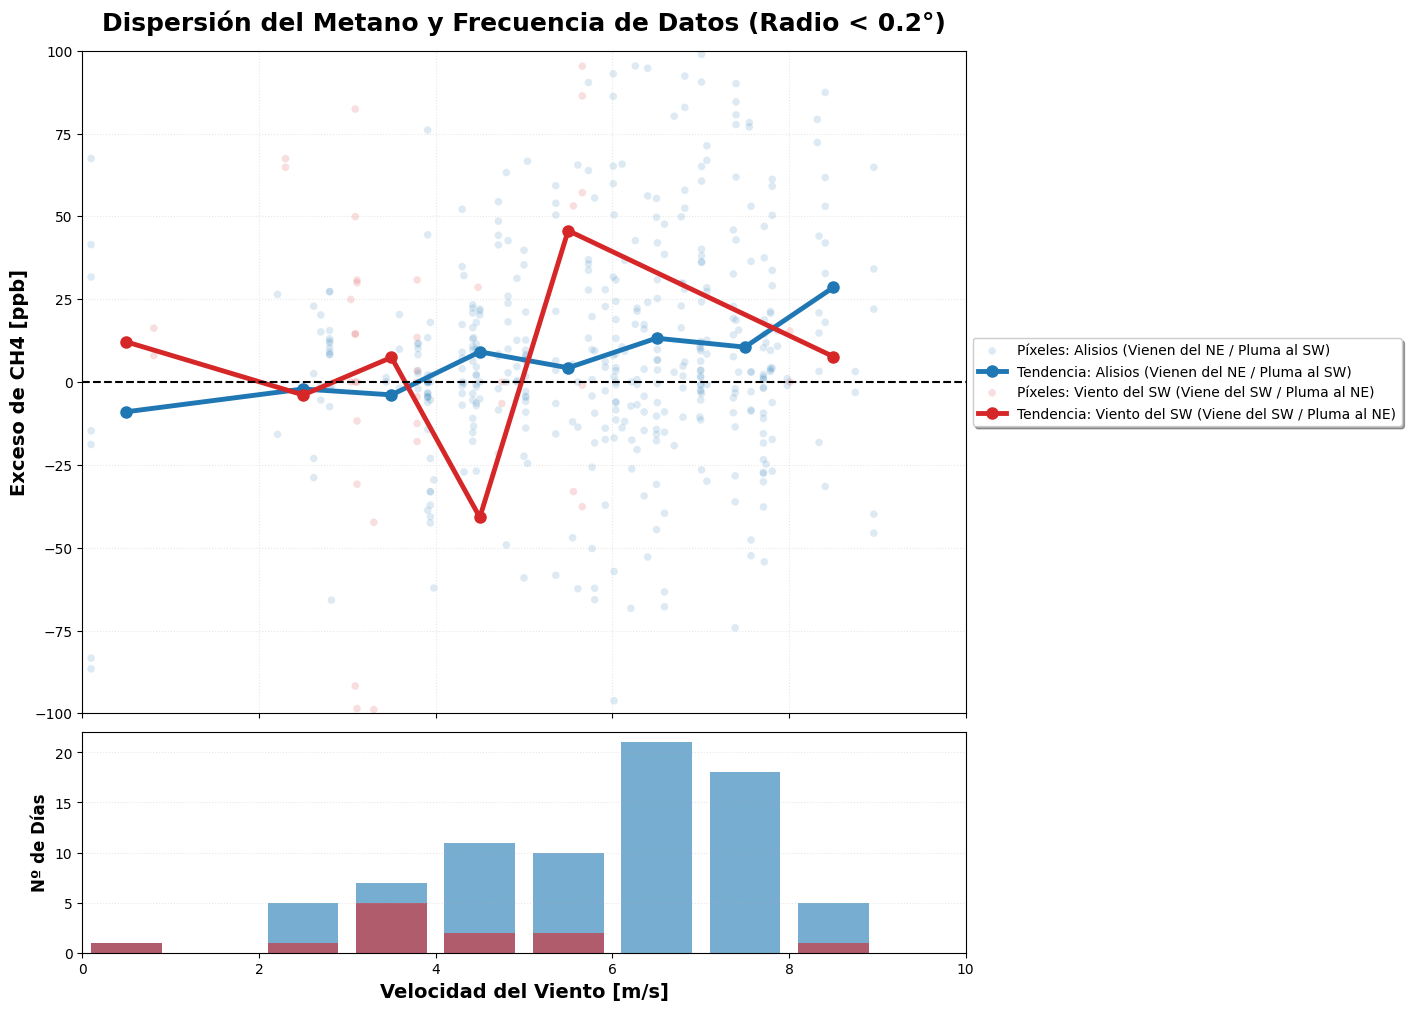

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PARÁMETROS GENERALES (Ajustados para ver la dispersión)
# ==============================================================================
# AQUÍ ESTÁ LA CLAVE: Dejamos entrar vientos de hasta 15 m/s
VIENTO_MIN, VIENTO_MAX = 0, 9

LAT_CENTRO, LON_CENTRO = 28.121479, -16.489068
QA_VALUE = 0.3
MASCARA_RADIO = 0.2
MASCARA_PIXEL = 2

print("1. Cargando datos...")
# Asegúrate de tener tu variable 'archivos' definida antes de esto con las rutas de tus CSV
df_list = [pd.read_csv(f) for f in archivos]
df = pd.concat(df_list, ignore_index=True)

# Filtros iniciales
df = df[(df['qa_value'] > QA_VALUE) &
        (df['v_modulo'] >= VIENTO_MIN) &
        (df['v_modulo'] <= VIENTO_MAX)].copy()

df['fecha'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True).dt.date
df['distancia'] = np.sqrt((df['lon'] - LON_CENTRO)**2 + (df['lat'] - LAT_CENTRO)**2)

# Filtro de días válidos
pixeles_cerca = df[df['distancia'] <= MASCARA_RADIO]
conteo_diario = pixeles_cerca.groupby('fecha').size()
dias_validos = conteo_diario[conteo_diario >= MASCARA_PIXEL].index
df = df[df['fecha'].isin(dias_validos)].copy()

df['dir_viento'] = (np.degrees(np.arctan2(-df['u10'], -df['v10']))) % 360

# ==============================================================================
# 2. CÁLCULO DE ANOMALÍA
# ==============================================================================
print("2. Calculando anomalías de metano...")
df['angulo_pixel'] = np.degrees(np.arctan2(df['lat'] - LAT_CENTRO, df['lon'] - LON_CENTRO)) % 360
df['dir_pluma'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360

diferencia_angular = np.abs(df['angulo_pixel'] - df['dir_pluma'])
diferencia_angular = np.minimum(diferencia_angular, 360 - diferencia_angular)

mask_barlovento = diferencia_angular > 90
mask_anillo_limpio = (df['distancia'] >= 0.05) & (df['distancia'] <= 0.4) & mask_barlovento

fondos_diarios = df[mask_anillo_limpio].groupby('fecha')['metano_ppb'].median()
fondos_respaldo = df.groupby('fecha')['metano_ppb'].median()
fondos_finales = fondos_diarios.combine_first(fondos_respaldo)

df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_finales)

# ==============================================================================
# 3. RECALCULO DE ANOMALÍA: MÉTODO DE MEDIANA REGIONAL (MÁS ROBUSTO)
# ==============================================================================
print("Recalculando anomalías usando Mediana Regional Local...")

# 1. Definimos un "anillo regional" (lejos de la pluma pero en la misma zona)
# Píxeles entre 0.15 y 0.5 grados de la fuente suelen ser buen fondo
RADIO_MIN_FONDO = 0.15
RADIO_MAX_FONDO = 0.4

def calcular_fondo_robusto(grupo_dia):
    # Intentamos coger solo píxeles que NO estén en la dirección de la pluma
    # pero para simplificar y ganar puntos, usaremos la mediana de los píxeles
    # que están en el anillo exterior.
    mask_anillo = (grupo_dia['distancia'] >= RADIO_MIN_FONDO) & \
                  (grupo_dia['distancia'] <= RADIO_MAX_FONDO)

    anillo_puntos = grupo_dia[mask_anillo]

    if len(anillo_puntos) > 5:
        # Usamos la mediana para ignorar píxeles ruidosos o nubes residuales
        return anillo_puntos['metano_ppb'].median()
    else:
        # Si no hay bastantes puntos en el anillo, usamos la mediana de todo el día
        return grupo_dia['metano_ppb'].median()

# Aplicamos el cálculo por cada día
fondos_regionales = df.groupby('fecha').apply(calcular_fondo_robusto)

# Creamos la nueva columna de anomalía
df['metano_anomalia'] = df['metano_ppb'] - df['fecha'].map(fondos_regionales)

print("Anomalías recalculadas. Ahora los excesos deberían ser más realistas.")
# ==============================================================================
# 7. METANO VS VIENTO + HISTOGRAMA DE FRECUENCIA
# ==============================================================================
print("\nGenerando gráfica de dispersión con histograma de frecuencia...")

RADIO_ANALISIS = 0.2
df_radio = df[df['distancia'] <= RADIO_ANALISIS].copy()

def clasificar_viento(angulo):
    if 0 <= angulo <= 90:
        return 'Alisios (Vienen del NE / Pluma al SW)'
    elif 180 <= angulo <= 270:
        return 'Viento del SW (Viene del SW / Pluma al NE)'
    else:
        return 'Otras direcciones'

df_radio['regimen_viento'] = df_radio['dir_viento'].apply(clasificar_viento)
df_radio['viento_grupo'] = np.floor(df_radio['v_modulo'])

# Creamos una figura con dos subgráficos (arriba dispersión, abajo histograma)
# height_ratios=[3, 1] hace que la de arriba sea 3 veces más alta que la de abajo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]},
                               constrained_layout=True)

colores = {
    'Alisios (Vienen del NE / Pluma al SW)': '#1f77b4',
    'Viento del SW (Viene del SW / Pluma al NE)': '#d62728'
}

# --- PARTE SUPERIOR: DISPERSIÓN ---
for regimen, color in colores.items():
    subset = df_radio[df_radio['regimen_viento'] == regimen]
    if len(subset) == 0: continue

    ax1.scatter(subset['v_modulo'], subset['metano_anomalia'],
               c=color, alpha=0.15, edgecolors='none', s=30, label=f'Píxeles: {regimen}')

    tendencia = subset.groupby('viento_grupo')['metano_anomalia'].mean()
    conteo = subset.groupby('viento_grupo').size()
    tendencia = tendencia[conteo >= 2]

    if not tendencia.empty:
        ax1.plot(tendencia.index + 0.5, tendencia.values,
                 color=color, marker='o', linewidth=3.5, markersize=8,
                 label=f'Tendencia: {regimen}')

ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.set_ylim(-100, 100)
ax1.set_ylabel("Exceso de CH4 [ppb]", fontsize=14, fontweight='bold')
ax1.set_title(f"Dispersión del Metano y Frecuencia de Datos (Radio < {RADIO_ANALISIS}°)", fontsize=18, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, shadow=True)

# --- PARTE INFERIOR: HISTOGRAMA (Días con datos) ---
# Para contar "días", primero agrupamos por fecha y régimen para tener el viento medio de cada día
df_dias = df_radio.groupby(['fecha', 'regimen_viento'])['v_modulo'].mean().reset_index()

for regimen, color in colores.items():
    subset_dias = df_dias[df_dias['regimen_viento'] == regimen]
    if len(subset_dias) == 0: continue

    # Dibujamos el histograma de días
    ax2.hist(subset_dias['v_modulo'], bins=np.arange(0, 11, 1),
             color=color, alpha=0.6, rwidth=0.8, label=regimen)

ax2.set_xlabel("Velocidad del Viento [m/s]", fontsize=14, fontweight='bold')
ax2.set_ylabel("Nº de Días", fontsize=12, fontweight='bold')
ax2.set_xlim(0, 10) # Ajustamos el límite según tus vientos
ax2.grid(axis='y', alpha=0.3, linestyle=':')

plt.show()

LA GRAFICA PARECE QUE INDICA QUE NO EXISTE UNA DEPENDENCIA FUERTE ENTRE VIENTO Y CONECNTRACION, TAMPOCO LA DIRECCION. LO QUE IMPLICA ESTE ANALISIS ES que la hipotesis inicial de que hay una fuente puntual de emision de metanmo que seria el vertedero, no se cumple, porque tendria qu ehaber una relsacion de cuanto menos viento mayor sea la emision de metano ya que se quedaria acumulada. si esto no es cierto, no hay ninguna fuente puntual, y seria mas consistente en que  hay otras fuentes de caracter difcuso en el sur de tenerife. y de donde viene el metano?? aeropuerto, del central termica de granadilla, tambien el vertedero, (buscar coche?? y que mas puede haber) recomemdacione sfuturas: si el tropomi no tiene capacidad sufieciente para realizar este tipo de analisis, podriamos realizar teledetccion en campo (ftirs) e insitu ( como el licor del proyecto de sergio donde se miido el co2).